In [ ]:
!pip install ultralytics

from ultralytics import YOLO
import torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install opencv-python
!pip install matplotlib


In [ ]:
import os
import shutil
import random
import yaml
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rakshi123","key":"4a05a4fd5e7fbc6a90725f723e4644f9"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d icebearogo/german-traffic-sign-detection-gtsdb-dataset


Dataset URL: https://www.kaggle.com/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
 66% 154M/234M [00:00<00:00, 1.61GB/s]
100% 234M/234M [00:00<00:00, 986MB/s] 


In [ ]:
!unzip german-traffic-sign-detection-gtsdb-dataset.zip

Archive:  german-traffic-sign-detection-gtsdb-dataset.zip
  inflating: GTSDB_Train_and_Test/ReadME__(yes actually take a look).txt  
  inflating: GTSDB_Train_and_Test/Test/images/00600.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00601.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00602.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00603.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00604.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00605.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00606.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00607.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00608.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00609.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00610.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00611.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00612.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00613.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00614.jpg

In [ ]:
!ls

 german-traffic-sign-detection-gtsdb-dataset.zip   kaggle.json
 GTSDB_Train_and_Test				   sample_data
'kaggle (1).json'


In [ ]:
!ls GTSDB_Train_and_Test

'ReadME__(yes actually take a look).txt'   Test   Train


In [ ]:
!ls GTSDB_Train_and_Test/Train

images	labels


In [ ]:
print("Train images:",
      len(os.listdir("/content/GTSDB_Train_and_Test/Train")))

print("Validation images:",
      len(os.listdir("/content/GTSDB_Train_and_Test/Test")))


Train images: 2
Validation images: 2


In [ ]:
import os

os.makedirs("datasets/traffic/images/train", exist_ok=True)
os.makedirs("datasets/traffic/images/val", exist_ok=True)
os.makedirs("datasets/traffic/images/test", exist_ok=True)

os.makedirs("datasets/traffic/labels/train", exist_ok=True)
os.makedirs("datasets/traffic/labels/val", exist_ok=True)
os.makedirs("datasets/traffic/labels/test", exist_ok=True)

print("Folders created!")


Folders created!


In [ ]:
import os
import random
import shutil

source_images = "GTSDB_Train_and_Test/Train/images"
source_labels = "GTSDB_Train_and_Test/Train/labels"

all_images = os.listdir(source_images)
random.shuffle(all_images)

split_index = int(0.8 * len(all_images))

train_imgs = all_images[:split_index]
val_imgs = all_images[split_index:]

# Copy train data
for img in train_imgs:
    shutil.copy(os.path.join(source_images, img),
                "datasets/traffic/images/train/" + img)

    label = img.replace(".jpg", ".txt")
    label_path = os.path.join(source_labels, label)

    if os.path.exists(label_path):
        shutil.copy(label_path,
                    "datasets/traffic/labels/train/" + label)

# Copy validation data
for img in val_imgs:
    shutil.copy(os.path.join(source_images, img),
                "datasets/traffic/images/val/" + img)

    label = img.replace(".jpg", ".txt")
    label_path = os.path.join(source_labels, label)

    if os.path.exists(label_path):
        shutil.copy(label_path,
                    "datasets/traffic/labels/val/" + label)

print("Train/Val split done successfully!")


Train/Val split done successfully!


In [ ]:
import os
import shutil

test_images = "GTSDB_Train_and_Test/Test/images"
test_labels = "GTSDB_Train_and_Test/Test/labels"

for img in os.listdir(test_images):

    # Copy image
    shutil.copy(os.path.join(test_images, img),
                "datasets/traffic/images/test/" + img)

    # Prepare label name
    label = img.replace(".jpg", ".txt")
    label_path = os.path.join(test_labels, label)

    # Copy only if label exists
    if os.path.exists(label_path):
        shutil.copy(label_path,
                    "datasets/traffic/labels/test/" + label)

print("Test data copied successfully!")


Test data copied successfully!


In [ ]:
print("Test Images:",
      len(os.listdir("datasets/traffic/images/test")))

print("Test Labels:",
      len(os.listdir("datasets/traffic/labels/test")))


Test Images: 300
Test Labels: 235


In [ ]:
import yaml
import os

traffic_yaml = {
    'path': os.path.abspath('datasets/traffic'),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 5,
    'names': ['speed_limit', 'stop', 'no_entry', 'yield', 'pedestrian_crossing']
}

with open('traffic.yaml', 'w') as f:
    yaml.dump(traffic_yaml, f)

print("traffic.yaml created successfully!")


traffic.yaml created successfully!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="traffic.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="task1_traffic"
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=traffic.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=task1_traffic, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e6f76fa5280>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
model = YOLO("runs/detect/task1_traffic/weights/best.pt")

val_metrics = model.val(data="traffic.yaml")

print("Validation mAP50:", val_metrics.box.map50)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3384.9±783.7 MB/s, size: 278.7 KB)
val: Scanning /content/datasets/traffic/labels/val.cache... 100 images, 20 backgrounds, 74 corrupt: 100% ━━━━━━━━━━━━ 120/120 36.0Mit/s 0.0s
val: /content/datasets/traffic/images/val/00010.jpg: ignoring corrupt image/label: Label class 12 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00020.jpg: ignoring corrupt image/label: Label class 23 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00023.jpg: ignoring corrupt image/label: Label class 23 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00028.jpg: ignoring corrupt image/label: Label class 35 exceeds dataset class count 5. Possib

In [ ]:
test_metrics = model.val(data="traffic.yaml", split="test")

print("Test mAP50:", test_metrics.box.map50)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2410.5±560.2 MB/s, size: 160.4 KB)
val: Scanning /content/datasets/traffic/labels/test... 235 images, 65 backgrounds, 186 corrupt: 100% ━━━━━━━━━━━━ 300/300 3.3Kit/s 0.1s
val: /content/datasets/traffic/images/test/00601.jpg: ignoring corrupt image/label: Label class 40 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/test/00602.jpg: ignoring corrupt image/label: Label class 41 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/test/00604.jpg: ignoring corrupt image/label: Label class 24 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/test/00605.jpg: ignoring corrupt image/label: Label class 34 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/test/00606.jpg: ign

In [ ]:
from ultralytics import YOLO

# Load traffic trained model
model = YOLO("runs/detect/task1_traffic/weights/best.pt")

print("Traffic model loaded successfully")


Traffic model loaded successfully


In [ ]:
traffic_model = YOLO("runs/detect/task1_traffic/weights/best.pt")
traffic_metrics = traffic_model.val(data="traffic.yaml")
print("Traffic mAP50:", traffic_metrics.box.map50)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3996.4±624.8 MB/s, size: 321.6 KB)
val: Scanning /content/datasets/traffic/labels/val.cache... 100 images, 20 backgrounds, 74 corrupt: 100% ━━━━━━━━━━━━ 120/120 36.0Mit/s 0.0s
val: /content/datasets/traffic/images/val/00010.jpg: ignoring corrupt image/label: Label class 12 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00020.jpg: ignoring corrupt image/label: Label class 23 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00023.jpg: ignoring corrupt image/label: Label class 23 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00028.jpg: ignoring corrupt image/label: Label class 35 exceeds dataset class count 5. Possib

In [ ]:
!kaggle datasets download -d abdallahwagih/cars-detection

Dataset URL: https://www.kaggle.com/datasets/abdallahwagih/cars-detection
License(s): apache-2.0
  0% 0.00/38.2M [00:00<?, ?B/s]
100% 38.2M/38.2M [00:00<00:00, 1.69GB/s]


In [ ]:
!unzip cars-detection.zip

Archive:  cars-detection.zip
  inflating: Cars Detection/data.yaml  
  inflating: Cars Detection/test/images/00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg  
  inflating: Cars Detection/test/images/00dea1edf14f09ab_jpg.rf.KJ730oDTFPdXdJxvSLnX.jpg  
  inflating: Cars Detection/test/images/00e481ea1a520175_jpg.rf.6e6a8b3b45c9a11d106958f88ff714ea.jpg  
  inflating: Cars Detection/test/images/00e481ea1a520175_jpg.rf.MV6sZ8QCFwFeMYaI2tHm.jpg  
  inflating: Cars Detection/test/images/08c8b73e0c2e296e_jpg.rf.7IkYAamjZhnwsoXSrwKt.jpg  
  inflating: Cars Detection/test/images/08c8b73e0c2e296e_jpg.rf.effa65856584463c08848031cab357b9.jpg  
  inflating: Cars Detection/test/images/10c26c6598677a1f_jpg.rf.USCbBYVcUICkLhuq07Lw.jpg  
  inflating: Cars Detection/test/images/10c26c6598677a1f_jpg.rf.f72b2b91e750909f68fffeee777e9350.jpg  
  inflating: Cars Detection/test/images/1ef77c61856d3b4b_jpg.rf.HZMSiUVx3WUcMIooJMZX.jpg  
  inflating: Cars Detection/test/images/1ef77c61856d3b4b_jpg.rf.

In [ ]:
import os

print(os.listdir())
print(os.listdir("Cars Detection"))


['.config', 'kaggle.json', 'yolo26n.pt', 'traffic.yaml', 'kaggle (1).json', 'cars-detection.zip', 'Cars Detection', 'german-traffic-sign-detection-gtsdb-dataset.zip', 'yolov8n.pt', 'GTSDB_Train_and_Test', 'runs', 'datasets', 'sample_data']
['train', 'data.yaml', 'valid', 'test']


In [ ]:
import yaml
import os

cars_yaml = {
    'path': os.path.abspath("Cars Detection"),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 5,
    'names': ['ambulance', 'bus', 'car', 'motorcycle', 'truck']
}

with open('cars.yaml', 'w') as f:
    yaml.dump(cars_yaml, f)

print("cars.yaml created successfully")


cars.yaml created successfully


In [ ]:
seq_model = YOLO("runs/detect/task1_traffic/weights/best.pt")

seq_model.train(
    data="cars.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    name="cars_without_CL"
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cars.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/task1_traffic/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cars_without_CL3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e70bdf2fe90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
cars_model = YOLO("runs/detect/cars_without_CL/weights/best.pt")

print("Cars mAP50:", cars_model.val(data="cars.yaml").box.map50)
print("Traffic mAP50 AFTER sequential:", cars_model.val(data="traffic.yaml").box.map50)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1156.8±511.1 MB/s, size: 31.0 KB)
val: Scanning /content/Cars Detection/valid/labels.cache... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 104.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.1it/s 3.9s
                   all        250        454       0.84     0.0269     0.0501     0.0252
             ambulance         50         64          1          0      0.109     0.0541
                   bus         30         46          1          0     0.0369     0.0199
                   car         90        238      0.202      0.134     0.0626     0.0361
            motorcycle         42         46          1          0     0.0124     0.0041
                 truck         38         

##**Reply Buffer**

In [ ]:
replay_ratio = 0.2
traffic_images = os.listdir("datasets/traffic/images/train")
replay_size = int(len(traffic_images) * replay_ratio)

replay_samples = random.sample(traffic_images, replay_size)

os.makedirs("datasets/replay/images", exist_ok=True)
os.makedirs("datasets/replay/labels", exist_ok=True)

for img in replay_samples:

    image_path = "datasets/traffic/images/train/" + img
    label_path = "datasets/traffic/labels/train/" + img.replace(".jpg",".txt")

    # Copy image
    shutil.copy(image_path,
                "datasets/replay/images/" + img)

    # Copy label ONLY if exists
    if os.path.exists(label_path):
        shutil.copy(label_path,
                    "datasets/replay/labels/" + img.replace(".jpg",".txt"))

print("Replay buffer created successfully (safe version)")


Replay buffer created successfully (safe version)


In [ ]:
for img in os.listdir("datasets/replay/images"):
    shutil.copy("datasets/replay/images/"+img,
                "Cars Detection/train/images/"+img)

for lbl in os.listdir("datasets/replay/labels"):
    shutil.copy("datasets/replay/labels/"+lbl,
                "Cars Detection/train/labels/"+lbl)


##**Save Old Weights**

In [ ]:
import copy

base_model = YOLO("runs/detect/task1_traffic/weights/best.pt")
old_weights = copy.deepcopy(base_model.model.state_dict())


##**Train With Replay**

In [ ]:
cl_model = YOLO("runs/detect/task1_traffic/weights/best.pt")

cl_model.train(
    data="cars.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    name="cars_with_replay"
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cars.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/task1_traffic/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cars_with_replay2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e6f7930eae0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

##**Elastic Weight Consolidation**

In [ ]:
new_model = YOLO("runs/detect/cars_with_replay2/weights/best.pt")
new_weights = new_model.model.state_dict()

lambda_ewc = 0.4

for key in new_weights:
    new_weights[key] = new_weights[key] - lambda_ewc*(new_weights[key] - old_weights[key])

new_model.model.load_state_dict(new_weights)
torch.save(new_model.model.state_dict(),"continual_model.pt")


##**Learning Without Forgetting**

In [ ]:
def lwf_loss(new_logits, old_logits, T=2):
    old_probs = F.softmax(old_logits/T, dim=1)
    new_log_probs = F.log_softmax(new_logits/T, dim=1)
    return F.kl_div(new_log_probs, old_probs, reduction='batchmean')*(T*T)


##**Final Evaluation**

In [ ]:
new_model = YOLO("runs/detect/cars_with_replay2/weights/best.pt")

new_weights = new_model.model.state_dict()

lambda_ewc = 0.4

for key in new_weights:
    new_weights[key] = new_weights[key] - lambda_ewc * (new_weights[key] - old_weights[key])

new_model.model.load_state_dict(new_weights)

new_model.save("continual_model.pt")

print("Continual model saved correctly")


Continual model saved correctly


In [ ]:
final_model = YOLO("continual_model.pt")


In [ ]:

print("Cars mAP50:", final_model.val(data="cars.yaml").box.map50)
print("Traffic mAP50 AFTER CL:", final_model.val(data="traffic.yaml").box.map50)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1171.2±350.6 MB/s, size: 31.4 KB)
val: Scanning /content/Cars Detection/valid/labels.cache... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 69.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.2it/s 3.8s
                   all        250        454     0.0561      0.843      0.222      0.149
             ambulance         50         64      0.108      0.938      0.397      0.298
                   bus         30         46      0.056      0.826      0.138      0.105
                   car         90        238     0.0639      0.706      0.239      0.149
            motorcycle         42         46     0.0247      0.913      0.214      0.113
                 truck         38         6

In [ ]:
traffic_map_before = traffic_model.val(data="traffic.yaml").box.map50

traffic_map_after = cars_model.val(data="traffic.yaml").box.map50
cars_map = cars_model.val(data="cars.yaml").box.map50

traffic_map_after_cl = final_model.val(data="traffic.yaml").box.map50
cars_map_cl = final_model.val(data="cars.yaml").box.map50

print("Traffic Before:", traffic_map_before)
print("Traffic After (No CL):", traffic_map_after)
print("Traffic After (With CL):", traffic_map_after_cl)
print("Cars mAP (No CL):", cars_map)
print("Cars mAP (With CL):", cars_map_cl)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 64.8±52.0 MB/s, size: 299.3 KB)
val: Scanning /content/datasets/traffic/labels/val.cache... 100 images, 20 backgrounds, 74 corrupt: 100% ━━━━━━━━━━━━ 120/120 33.6Mit/s 0.0s
val: /content/datasets/traffic/images/val/00010.jpg: ignoring corrupt image/label: Label class 12 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00020.jpg: ignoring corrupt image/label: Label class 23 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00023.jpg: ignoring corrupt image/label: Label class 23 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00028.jpg: ignoring corrupt image/label: Label class 35 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00032.jpg: ignori

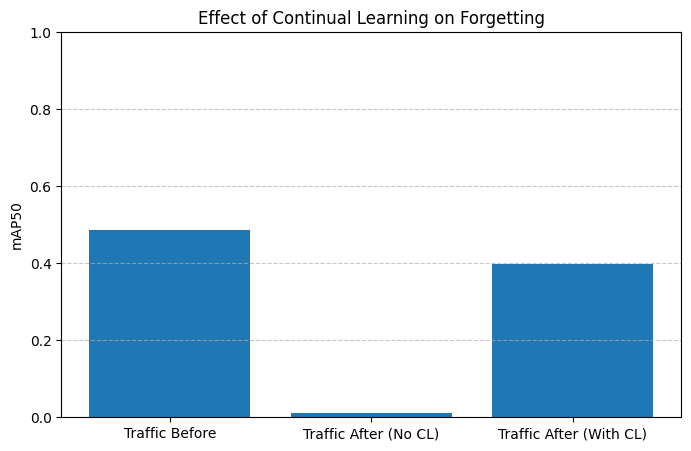

Forgetting Without CL: 0.4762454869774641
Forgetting With CL: 0.08876271780915357


In [ ]:
labels = ['Traffic Before',
          'Traffic After (No CL)',
          'Traffic After (With CL)']

values = [traffic_map_before,
          traffic_map_after,
          traffic_map_after_cl]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylabel("mAP50")
plt.title("Effect of Continual Learning on Forgetting")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Forgetting Without CL:", traffic_map_before - traffic_map_after)
print("Forgetting With CL:", traffic_map_before - traffic_map_after_cl)
